# Goal

We will use Inheritance as the target variable to predict inheritance pattern of a disease.

# Spark Initialization

In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("RareDiseaseInheritancePipeline")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

# Data Loading

In [2]:
df = spark.read.csv(
    "rare_diseases_complete.csv",
    header = True,
    inferSchema = True
)

# Exploratory Data Analysis

In [3]:
df.printSchema()

root
 |-- OrphaCode: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- DisorderType: string (nullable = true)
 |-- DisorderGroup: string (nullable = true)
 |-- ICD-11: string (nullable = true)
 |-- MONDO: integer (nullable = true)
 |-- ICD-10: string (nullable = true)
 |-- OMIM: integer (nullable = true)
 |-- UMLS: string (nullable = true)
 |-- MeSH: string (nullable = true)
 |-- MedDRA: integer (nullable = true)
 |-- GARD: integer (nullable = true)
 |-- DiseaseName: string (nullable = true)
 |-- AgeOfOnset: string (nullable = true)
 |-- TypeOfInheritance: string (nullable = true)



In [4]:
print(df.count(), len(df.columns))

11456 15


In [5]:
print(df.columns)

['OrphaCode', 'Name', 'DisorderType', 'DisorderGroup', 'ICD-11', 'MONDO', 'ICD-10', 'OMIM', 'UMLS', 'MeSH', 'MedDRA', 'GARD', 'DiseaseName', 'AgeOfOnset', 'TypeOfInheritance']


In [6]:
df.show(5)

+---------+--------------------+------------+-------------+-------+-----+------+------+--------+-------+--------+----+--------------------+--------------------+-------------------+
|OrphaCode|                Name|DisorderType|DisorderGroup| ICD-11|MONDO|ICD-10|  OMIM|    UMLS|   MeSH|  MedDRA|GARD|         DiseaseName|          AgeOfOnset|  TypeOfInheritance|
+---------+--------------------+------------+-------------+-------+-----+------+------+--------+-------+--------+----+--------------------+--------------------+-------------------+
|   166024|Multiple epiphyse...|     Disease|     Disorder|LD24.61|11778| Q77.3|607131|C4304500|   NULL|    NULL|NULL|Multiple epiphyse...|   Infancy, Neonatal|Autosomal recessive|
|   166032|Multiple epiphyse...|     Disease|     Disorder|LD24.61|12254| Q77.3|609325|C5924992|C563735|    NULL|NULL|Multiple epiphyse...|  Childhood, Infancy|               NULL|
|       58|   Alexander disease|     Disease|     Disorder| 8A44.2| 8752| G93.8|203450|C0270726

In [7]:
sum_df = df.summary().toPandas()
sum_df

,summary,OrphaCode,Name,DisorderType,DisorderGroup,ICD-11,MONDO,ICD-10,OMIM,UMLS,MeSH,MedDRA,GARD,DiseaseName,AgeOfOnset,TypeOfInheritance
0,count,11456,11456,11456,11456,6143,7988,7541,4978,9634,3216,1805,3833,7374,6781,6238
1,mean,212643.36478701117,NaN,NaN,NaN,2.00000001E90,51331.50162744116,NaN,429008.9724789072,NaN,NaN,1.0052254210526315E7,6931.687711974954,NaN,NaN,NaN
2,stddev,205123.85099399634,NaN,NaN,NaN,6.324555316823118E90,243303.93848069807,NaN,201254.68385359203,NaN,NaN,25941.082319923633,4784.269616062984,NaN,NaN,NaN
3,min,5,10p13-p14 deletion syndrome,Biological anomaly,Disorder,1A00,44,A00.0,100100,C0000744,C000591739,10000002,1,10p13-p14 deletion syndrome,Adolescent,Autosomal dominant
4,25%,57194,NaN,NaN,NaN,6.0E21,10554,NaN,231005,NaN,NaN,10030286,3098,NaN,NaN,NaN
5,50%,139450,NaN,NaN,NaN,8.0E45,15790,NaN,601612,NaN,NaN,10057271,6381,NaN,NaN,NaN
6,75%,317428,NaN,NaN,NaN,1.0E74,18776,NaN,614378,NaN,NaN,10073472,10142,NaN,NaN,NaN
7,max,718255,Åland Islands eye disease,Particular clinical situation in a disease or ...,Subtype of disorder,XH9T74,8000012,Z94.8,621394,C5925149,D065817,10090652,22310,Åland Islands eye disease,No data available,X-linked recessive


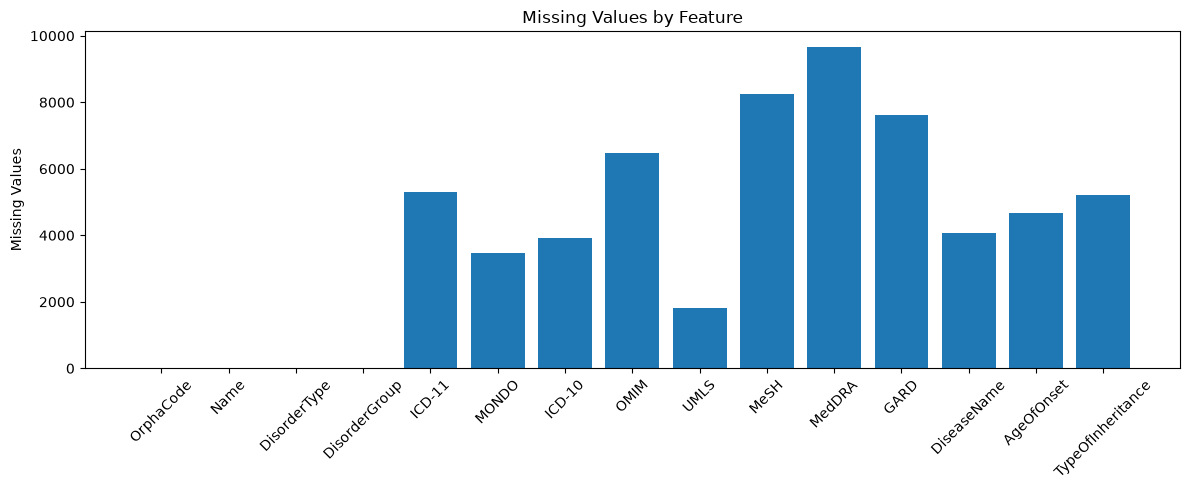

In [8]:
# Missing Values Distribution Plot

from pyspark.sql.functions import col, when, count
import matplotlib.pyplot as plt

missing = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).toPandas().T

missing.columns = ["Missing"]
missing = missing.reset_index().rename(columns={"index":"Feature"})

plt.figure(figsize=(12,5))
plt.bar(missing["Feature"], missing["Missing"])
plt.xticks(rotation=45)
plt.ylabel("Missing Values")
plt.title("Missing Values by Feature")
plt.tight_layout()
plt.show()

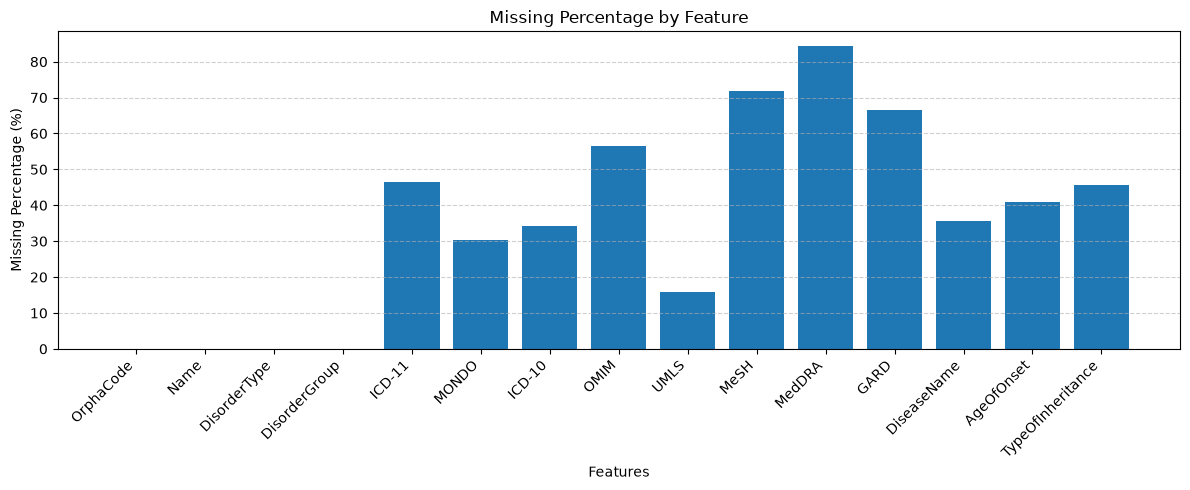

In [9]:
# Missing Percentage Plot

total_rows = df.count()
missing["Missing %"] = (missing["Missing"] / total_rows) * 100
plt.figure(figsize=(12, 5))
plt.bar(missing["Feature"], missing["Missing %"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Missing Percentage (%)")
plt.xlabel("Features")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.title("Missing Percentage by Feature")
plt.tight_layout()
plt.show()


In [10]:
for c in df.columns:
    print(c)
    print(df.select(c).distinct().count())

OrphaCode


11456
Name


11456
DisorderType
11
DisorderGroup
3
ICD-11


2280
MONDO
7989
ICD-10


1744
OMIM
4421
UMLS


9631
MeSH
3217
MedDRA


1806
GARD
3834
DiseaseName


7375
AgeOfOnset
63
TypeOfInheritance
68


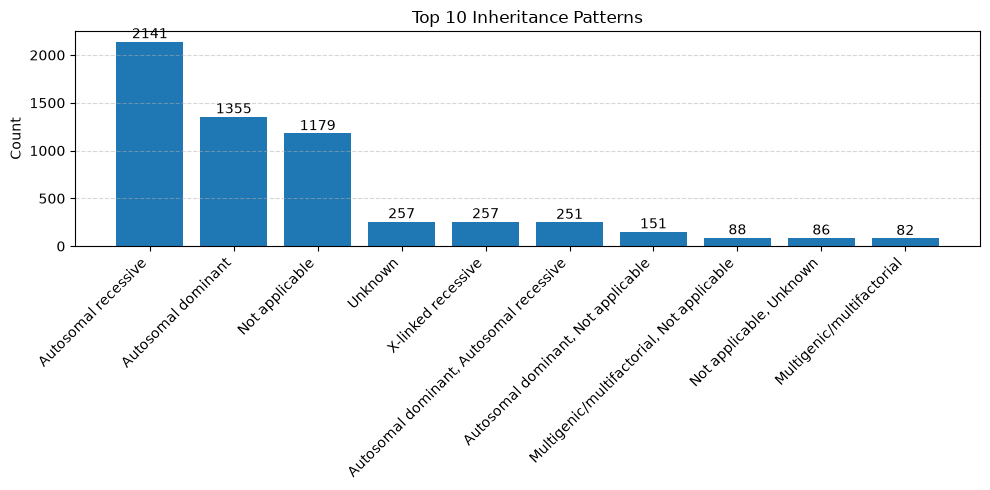

In [11]:
# Disorder Distribution Plot
inheritance_counts = df.groupBy("TypeOfInheritance").count().toPandas()
inheritance_counts = inheritance_counts.dropna(subset=["TypeOfInheritance"])
inheritance_counts = inheritance_counts.sort_values("count", ascending=False).head(10)

plt.figure(figsize=(10, 5))
bars = plt.bar(inheritance_counts["TypeOfInheritance"], inheritance_counts["count"])

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.5, str(int(h)), ha="center", va="bottom")

plt.title("Top 10 Inheritance Patterns")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Preprocessing and Target Policy

Rows with a known `TypeOfInheritance` are used for supervised training. Rows where the target is missing are preserved for prediction after model selection. Rare inheritance labels are grouped to make the multiclass evaluation more stable.

In [12]:
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import IndexToString, OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.functions import vector_to_array

SEED = 42
MIN_CLASS_COUNT = 20

categorical_cols = ["DisorderType", "DisorderGroup", "AgeOfOnset"]
target_col = "TypeOfInheritance"
code_system_cols = ["ICD-11", "MONDO", "ICD-10", "OMIM", "UMLS", "MeSH", "MedDRA", "GARD"]
code_feature_cols = [
    "has_icd11", "has_mondo", "has_icd10", "has_omim",
    "has_umls", "has_mesh", "has_meddra", "has_gard",
]

# Normalize blank strings and make missing feature values explicit.
modeling_df = df
for column_name in categorical_cols + [target_col]:
    normalized = F.trim(F.col(column_name).cast("string"))
    modeling_df = modeling_df.withColumn(
        column_name,
        F.when(normalized.isNull() | (normalized == ""), F.lit(None)).otherwise(normalized),
    )

modeling_df = modeling_df.fillna("Unknown", subset=categorical_cols)
modeling_df = modeling_df.withColumn(
    "DisplayDiseaseName",
    F.coalesce(F.col("DiseaseName"), F.col("Name"), F.lit("Unknown disease")),
)

# Use code-system availability as structured signal without treating identifiers as quantities.
for source_column, feature_column in zip(code_system_cols, code_feature_cols):
    modeling_df = modeling_df.withColumn(
        feature_column,
        F.when(F.col(source_column).isNotNull(), F.lit(1.0)).otherwise(F.lit(0.0)),
    )
modeling_df = modeling_df.withColumn(
    "code_system_count",
    sum((F.col(column_name) for column_name in code_feature_cols), F.lit(0.0)),
)

# Group very small known classes; never fill or impute a missing target label.
class_counts = (
    modeling_df.filter(F.col(target_col).isNotNull())
    .groupBy(target_col)
    .count()
)
rare_labels = [
    row[target_col]
    for row in class_counts.filter(F.col("count") < MIN_CLASS_COUNT).collect()
]

if rare_labels:
    modeling_df = modeling_df.withColumn(
        "ModelTarget",
        F.when(F.col(target_col).isNull(), F.lit(None))
        .when(F.col(target_col).isin(rare_labels), F.lit("Other rare/combined"))
        .otherwise(F.col(target_col)),
    )
else:
    modeling_df = modeling_df.withColumn("ModelTarget", F.col(target_col))

labeled_df = modeling_df.filter(F.col("ModelTarget").isNotNull())
unlabeled_df = modeling_df.filter(F.col(target_col).isNull())

print(f"Total rows: {modeling_df.count():,}")
print(f"Labeled rows used for modeling: {labeled_df.count():,}")
print(f"Unlabeled rows retained for prediction: {unlabeled_df.count():,}")
print(f"Rare raw labels grouped: {len(rare_labels)}")

Total rows: 11,456
Labeled rows used for modeling: 6,238
Unlabeled rows retained for prediction: 5,218
Rare raw labels grouped: 52


In [13]:
model_target_distribution = (
    labeled_df.groupBy("ModelTarget")
    .count()
    .orderBy(F.desc("count"))
)
model_target_distribution.show(30, truncate=False)

+-----------------------------------------------------------+-----+
|ModelTarget                                                |count|
+-----------------------------------------------------------+-----+
|Autosomal recessive                                        |2141 |
|Autosomal dominant                                         |1355 |
|Not applicable                                             |1179 |
|X-linked recessive                                         |257  |
|Unknown                                                    |257  |
|Autosomal dominant, Autosomal recessive                    |251  |
|Other rare/combined                                        |198  |
|Autosomal dominant, Not applicable                         |151  |
|Multigenic/multifactorial, Not applicable                  |88   |
|Not applicable, Unknown                                    |86   |
|Multigenic/multifactorial                                  |82   |
|X-linked dominant                              

# Train/Test Split and Feature Pipeline

In [14]:
train_raw, test_raw = labeled_df.randomSplit([0.8, 0.2], seed=SEED)

# Fit the label mapping on training data only.
label_indexer_model = StringIndexer(
    inputCol="ModelTarget",
    outputCol="label",
    handleInvalid="skip",
    stringOrderType="frequencyDesc",
).fit(train_raw)

train_data = label_indexer_model.transform(train_raw)
test_data = label_indexer_model.transform(test_raw)

indexed_cols = [f"{column_name}_Index" for column_name in categorical_cols]
encoded_cols = [f"{column_name}_Vec" for column_name in categorical_cols]

feature_stages = [
    StringIndexer(
        inputCol=column_name,
        outputCol=f"{column_name}_Index",
        handleInvalid="keep",
        stringOrderType="frequencyDesc",
    )
    for column_name in categorical_cols
]
feature_stages.extend(
    [
        OneHotEncoder(inputCols=indexed_cols, outputCols=encoded_cols),
        VectorAssembler(
            inputCols=code_feature_cols + ["code_system_count"] + encoded_cols,
            outputCol="features",
        ),
    ]
)

print(f"Training rows: {train_data.count():,}")
print(f"Test rows: {test_data.count():,}")
print(f"Modeled target classes: {len(label_indexer_model.labels)}")

Training rows: 5,045
Test rows: 1,193
Modeled target classes: 16


# Model Training and Evaluation

In [15]:
evaluators = {
    "accuracy": MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="accuracy"
    ),
    "weighted_precision": MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="weightedPrecision"
    ),
    "weighted_recall": MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="weightedRecall"
    ),
    "weighted_f1": MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="f1"
    ),
}

train_target_counts = train_data.groupBy("label").count().collect()
majority_label = float(max(train_target_counts, key=lambda row: row["count"])["label"])
baseline_predictions = test_data.withColumn("prediction", F.lit(majority_label))

metric_rows = [
    {
        "model": "majority_class_baseline",
        **{
            metric_name: round(float(evaluator.evaluate(baseline_predictions)), 4)
            for metric_name, evaluator in evaluators.items()
        },
    }
]

model_estimators = {
    "logistic_regression": LogisticRegression(
        labelCol="label",
        featuresCol="features",
        family="multinomial",
        maxIter=80,
        regParam=0.05,
        elasticNetParam=0.0,
    ),
    "random_forest": RandomForestClassifier(
        labelCol="label",
        featuresCol="features",
        numTrees=100,
        maxDepth=8,
        seed=SEED,
    ),
}

fitted_models = {}
scored_tests = {}

for model_name, estimator in model_estimators.items():
    fitted_models[model_name] = Pipeline(stages=feature_stages + [estimator]).fit(train_data)
    scored_tests[model_name] = fitted_models[model_name].transform(test_data)
    metric_rows.append(
        {
            "model": model_name,
            **{
                metric_name: round(float(evaluator.evaluate(scored_tests[model_name])), 4)
                for metric_name, evaluator in evaluators.items()
            },
        }
    )

metrics_df = spark.createDataFrame(metric_rows).select(
    "model", "accuracy", "weighted_precision", "weighted_recall", "weighted_f1"
)
metrics_df.orderBy(F.desc("weighted_f1")).show(truncate=False)

selected_result = max(
    [row for row in metric_rows if row["model"] != "majority_class_baseline"],
    key=lambda row: row["weighted_f1"],
)
selected_model_name = selected_result["model"]
selected_model = fitted_models[selected_model_name]
print(f"Selected model: {selected_model_name}")

+-----------------------+--------+------------------+---------------+-----------+
|model                  |accuracy|weighted_precision|weighted_recall|weighted_f1|
+-----------------------+--------+------------------+---------------+-----------+
|logistic_regression    |0.5046  |0.4026            |0.5046         |0.4206     |
|random_forest          |0.4996  |0.3915            |0.4996         |0.3878     |
|majority_class_baseline|0.3345  |0.1119            |0.3345         |0.1676     |
+-----------------------+--------+------------------+---------------+-----------+

Selected model: logistic_regression


# Prediction Results

In [16]:
label_decoder = IndexToString(
    inputCol="prediction",
    outputCol="Predicted_Inheritance",
    labels=label_indexer_model.labels,
)

test_predictions = label_decoder.transform(scored_tests[selected_model_name]).withColumn(
    "Prediction_Confidence",
    F.array_max(vector_to_array(F.col("probability"))),
)

test_prediction_output = test_predictions.select(
    "OrphaCode",
    F.col("DisplayDiseaseName").alias("DiseaseName"),
    F.col(target_col).alias("Actual_Inheritance"),
    "Predicted_Inheritance",
    "Prediction_Confidence",
)

test_prediction_output.orderBy(F.desc("Prediction_Confidence")).show(20, truncate=False)

+---------+------------------------------------------------------------------------+---------------------------+---------------------+---------------------+
|OrphaCode|DiseaseName                                                             |Actual_Inheritance         |Predicted_Inheritance|Prediction_Confidence|
+---------+------------------------------------------------------------------------+---------------------------+---------------------+---------------------+
|411527   |Central retinal vein occlusion                                          |Not applicable             |Not applicable       |0.9683305065927603   |
|263310   |Thymoma type A                                                          |Not applicable             |Not applicable       |0.945797275206898    |
|268316   |Complication in hemodialysis                                            |Not applicable             |Not applicable       |0.9438104365639818   |
|90081    |AIDS wasting syndrome                          

In [17]:
unlabeled_predictions = label_decoder.transform(
    selected_model.transform(unlabeled_df)
).withColumn(
    "Prediction_Confidence",
    F.array_max(vector_to_array(F.col("probability"))),
)

unlabeled_prediction_output = unlabeled_predictions.select(
    "OrphaCode",
    F.col("DisplayDiseaseName").alias("DiseaseName"),
    "Predicted_Inheritance",
    "Prediction_Confidence",
)

test_output_path = "rare_diseases_test_predictions"
unlabeled_output_path = "rare_diseases_unlabeled_predictions"

test_prediction_output.coalesce(1).write.mode("overwrite").option("header", True).csv(test_output_path)
unlabeled_prediction_output.coalesce(1).write.mode("overwrite").option("header", True).csv(
    unlabeled_output_path
)

print(f"Saved held-out test predictions to: {test_output_path}/")
print(f"Saved missing-label prediction candidates to: {unlabeled_output_path}/")
print(f"Missing-label predictions generated: {unlabeled_prediction_output.count():,}")
unlabeled_prediction_output.orderBy(F.desc("Prediction_Confidence")).show(20, truncate=False)

Saved held-out test predictions to: rare_diseases_test_predictions/
Saved missing-label prediction candidates to: rare_diseases_unlabeled_predictions/
Missing-label predictions generated: 5,218
+---------+------------------------------------------------------------------------+---------------------+---------------------+
|OrphaCode|DiseaseName                                                             |Predicted_Inheritance|Prediction_Confidence|
+---------+------------------------------------------------------------------------+---------------------+---------------------+
|402035   |Eosinophilic colitis                                                    |Not applicable       |0.9900477955616728   |
|494448   |Vulvar squamous cell carcinoma                                          |Not applicable       |0.9867051500660226   |
|494451   |Vulvar basal cell carcinoma                                             |Not applicable       |0.9867051500660226   |
|494454   |Vulvar adenocarcinoma

# Conclusion

The workflow now runs from raw data through preprocessing, held-out model comparison, human-readable test predictions, and candidate predictions for diseases whose inheritance label is missing. The predictions are exploratory analytical candidates and are not intended for clinical decision-making.

In [18]:
print(f"Final selected model: {selected_model_name}")
print(f"Test accuracy: {selected_result['accuracy']:.4f}")
print(f"Test weighted F1: {selected_result['weighted_f1']:.4f}")
spark.stop()
print("Spark session stopped. Pipeline completed successfully.")

Final selected model: logistic_regression
Test accuracy: 0.5046
Test weighted F1: 0.4206


Spark session stopped. Pipeline completed successfully.
